# News Silver EDA
EDA riêng cho chất lượng, nội dung, nguồn và ticker của Silver News.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
ROOT = Path.cwd().parent if Path.cwd().name == 'eda' else Path.cwd()
news = pd.read_parquet(ROOT / 'data_lake/silver/news')
news['published_timestamp'] = pd.to_datetime(news['published_timestamp'], utc=True)
news['published_month'] = news['published_timestamp'].dt.tz_convert('Asia/Ho_Chi_Minh').dt.to_period('M').astype(str)
print(f'News rows: {len(news):,}')

News rows: 2,879


/tmp/ipykernel_911957/3659161383.py:8: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  news['published_month'] = news['published_timestamp'].dt.tz_convert('Asia/Ho_Chi_Minh').dt.to_period('M').astype(str)


In [2]:
quality = pd.Series({
    'rows': len(news),
    'distinct_event_id': news.event_id.nunique(),
    'duplicate_url': news.url.dropna().duplicated().sum(),
    'duplicate_content_hash': news.content_hash.dropna().duplicated().sum(),
    'invalid_rows': (~news.is_valid).sum(),
    'missing_title': news.title.fillna('').str.strip().eq('').sum(),
    'full_article': news.has_full_text.sum(),
    'metadata_only': (~news.has_full_text).sum(),
    'with_vn30_ticker': news.merged_tickers.map(len).gt(0).sum(),
}, name='value').to_frame()
display(quality)

,value
rows,2879
distinct_event_id,2879
duplicate_url,0
duplicate_content_hash,1
invalid_rows,0
missing_title,0
full_article,2707
metadata_only,172
with_vn30_ticker,2879


In [3]:
date_range = news[['published_timestamp']].agg(['min','max'])
display(date_range)

,published_timestamp
min,2020-01-01 08:00:00+00:00
max,2026-10-06 10:07:00+00:00


,articles,rate_pct
has_full_text,,
Full article,2707,94.03
Metadata only,172,5.97


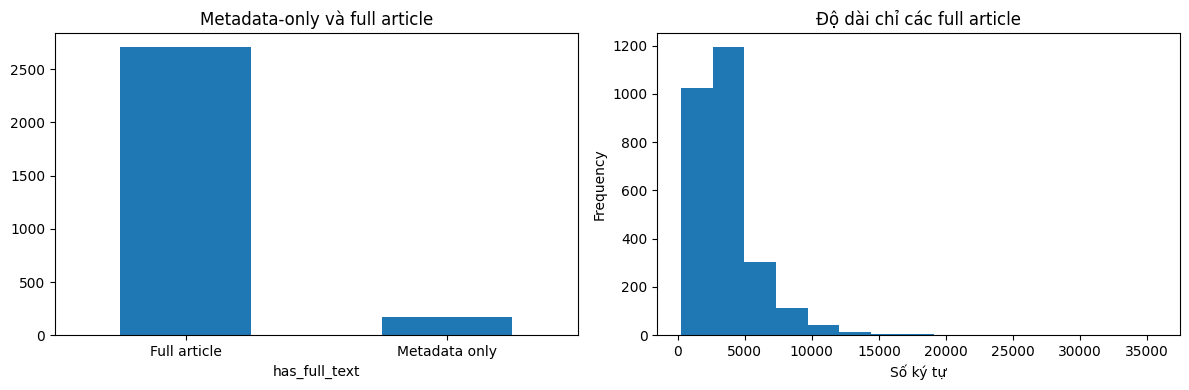

In [4]:
content_status = news.has_full_text.map({True: 'Full article', False: 'Metadata only'}).value_counts()
full_lengths = news.loc[news.has_full_text, 'content_length']
display(pd.DataFrame({
    'articles': content_status,
    'rate_pct': (100 * content_status / len(news)).round(2),
}))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
content_status.plot.bar(ax=axes[0], title='Metadata-only và full article', rot=0)
full_lengths.plot.hist(bins=15, ax=axes[1], title='Độ dài chỉ các full article')
axes[1].set_xlabel('Số ký tự')
plt.tight_layout(); plt.show()

In [5]:
full_length_summary = full_lengths.describe().to_frame('full_article_length')
display(full_length_summary)

,full_article_length
count,2707.000000
mean,3632.920207
std,2338.011982
min,241.000000
25%,2109.000000
50%,3093.000000
75%,4431.500000
max,35666.000000


,articles,full_articles,full_text_rate_pct
source,,,
cafef,472,464,98.31
chungta,319,299,93.73
fpt shop,144,144,100.00
báo dân trí,122,121,99.18
báo thanh niên,92,92,100.00
kenh14.vn,91,89,97.80
baonghean.vn,87,87,100.00
báo tuổi trẻ,87,87,100.00
vnexpress,77,77,100.00


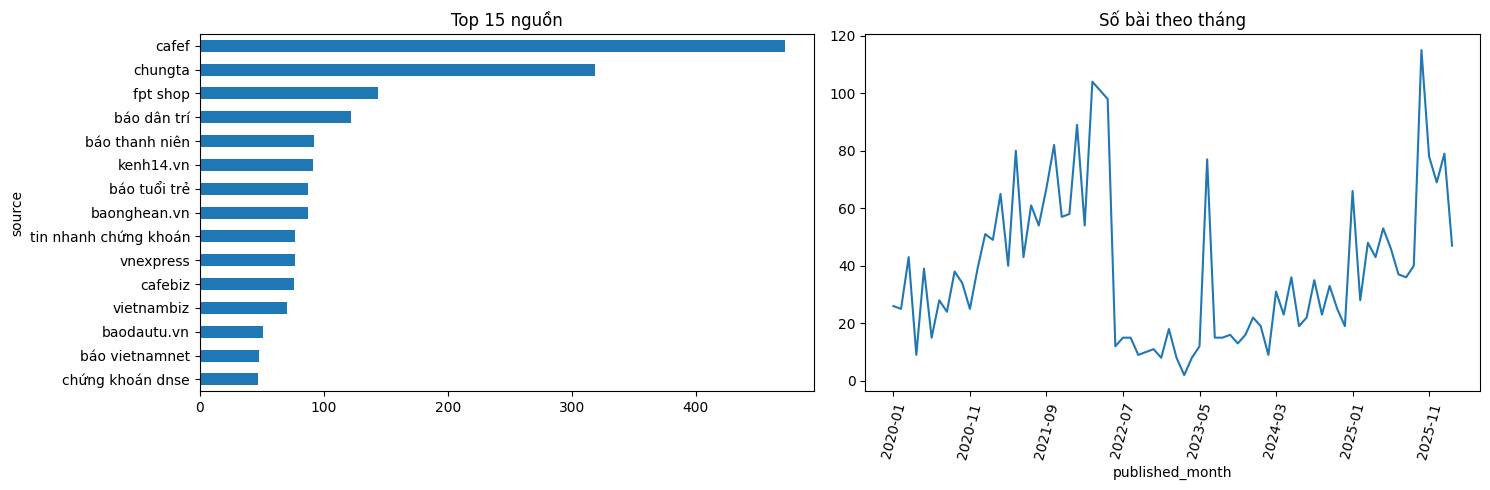

In [6]:
source_stats = news.groupby('source').agg(
    articles=('event_id','size'),
    full_articles=('has_full_text','sum'),
).sort_values('articles', ascending=False)
source_stats['full_text_rate_pct'] = (100 * source_stats.full_articles / source_stats.articles).round(2)
display(source_stats.head(20))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
source_stats.head(15).sort_values('articles').articles.plot.barh(ax=axes[0], title='Top 15 nguồn')
news.groupby('published_month').size().plot(ax=axes[1], title='Số bài theo tháng')
axes[1].tick_params(axis='x', rotation=75)
plt.tight_layout(); plt.show()

In [7]:
ticker_counts = news.explode('merged_tickers').merged_tickers.value_counts()
ticker_pairs = [(list(r), list(n)) for r,n in zip(news.rulebased_tickers, news.ner_tickers)]
agreement = pd.Series({
    'rule_ner_agree': sum(set(r) == set(n) and len(r) > 0 for r,n in ticker_pairs),
    'rule_only': sum(len(r) > 0 and len(n) == 0 for r,n in ticker_pairs),
    'ner_only': sum(len(n) > 0 and len(r) == 0 for r,n in ticker_pairs),
    'partial_disagreement': sum(len(r) > 0 and len(n) > 0 and set(r) != set(n) for r,n in ticker_pairs),
})
display(agreement.to_frame('articles'))

,articles
rule_ner_agree,1980
rule_only,673
ner_only,10
partial_disagreement,216


,mentions
merged_tickers,
FPT,1316
ACB,1075
CTG,334
VCB,298
TCB,189
BID,178
VPB,159
STB,129
BCM,128


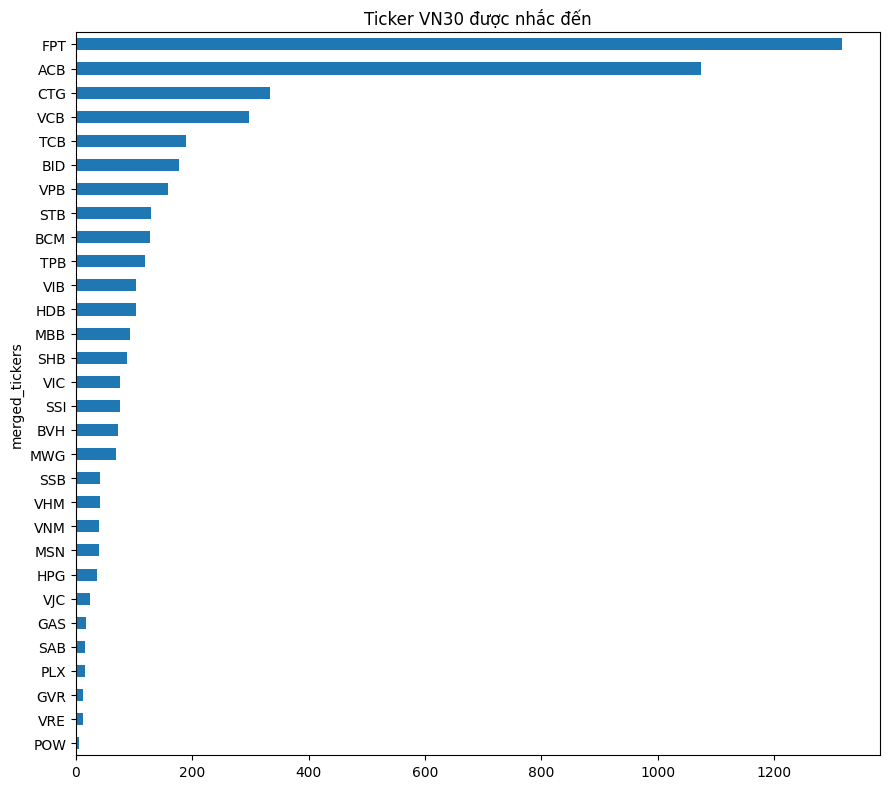

In [8]:
display(ticker_counts.to_frame('mentions'))
ticker_counts.sort_values().plot.barh(figsize=(9,8), title='Ticker VN30 được nhắc đến')
plt.tight_layout(); plt.show()